In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import fft

In [2]:
# create original unit cell lattice vectors
a1 = (np.sqrt(3)/2, 0.5)
a2 = (-np.sqrt(3)/2, 0.5)
a3 = (0.0, -1.0)

# Create the original unit cell reciprocal Lattice
g1 = 2*np.pi/3*np.array([np.sqrt(3), 3.0])
g2 = 2*np.pi/3*np.array([-np.sqrt(3), 3.0])

# 3 site unit cell basis vectors (different gauge)
b1m = 3*a1
b2m = a2

# reciprocal lattice vectors of 3 site unit cell (different gauge)
h1m = g1/3
h2m = g2

# 6 site unit cell basis vectors (different gauge)
b1mm = 6*a1
b2mm = a2

# reciprocal lattice vectors of 6 site unit cell (different gauge)
h1mm = g1/6
h2mm = g2

In [21]:
# create momentum grid, spanned by vectors vec1 and vec2

def get_mom_grid_6sUC(L6, vec1, vec2):
    """
    Build a 2D momentum grid centered around q = (0, 0)
    for a lattice with reciprocal vectors vec1, vec2.
    """
    dg1 = vec1 / L6
    dg2 = vec2 / (6*L6)

    # range of indices, symmetric around zero
    idx = np.arange(-L6//2, L6//2)
    idy = np.arange(-(6*L6)//2, (6*L6)//2)

    momGrid = np.zeros((6*L6*L6, 2), dtype=float)
    momGridMat = np.zeros((L6, 6*L6, 2), dtype=float)

    for i, n1 in enumerate(idx):
        for j, n2 in enumerate(idy):
            q_vec = n1 * dg1 + n2 * dg2
            momGrid[i*L6 + j] = q_vec
            momGridMat[i, j] = q_vec

    return momGrid, momGridMat

def get_mom_grid_3sUC(L3, vec1, vec2):
    """
    Build a 2D momentum grid centered around q = (0, 0)
    for a lattice with reciprocal vectors vec1, vec2.
    """
    dg1 = vec1 / L3
    dg2 = vec2 / (3*L3)

    # range of indices, symmetric around zero
    idx = np.arange(-L3//2, L3//2)
    idy = np.arange(-(3*L3)//2, (3*L3)//2)

    momGrid = np.zeros((3*L3*L3, 2), dtype=float)
    momGridMat = np.zeros((L3, 3*L3, 2), dtype=float)

    for i, n1 in enumerate(idx):
        for j, n2 in enumerate(idy):
            q_vec = n1 * dg1 + n2 * dg2
            momGrid[i*L3 + j] = q_vec
            momGridMat[i, j] = q_vec

    return momGrid, momGridMat

def get_electron_mom_grid(L, vec1, vec2):
    dg1 = vec1 / L
    dg2 = vec2 / L

    # range of indices, symmetric around zero
    idx = np.arange(-L//2, L//2)
    idy = np.arange(-L//2, L//2)

    EmomGrid = np.zeros((L*L, 2), dtype=float)
    EmomGridMat = np.zeros((L, L, 2), dtype=float)

    for i, n1 in enumerate(idx):
        for j, n2 in enumerate(idy):
            q_vec = n1 * dg1 + n2 * dg2
            EmomGrid[i*L + j] = q_vec
            EmomGridMat[i, j] = q_vec

    return EmomGrid, EmomGridMat


# Hamiltonian for the Partons
def Ham_Partons_6sUC(k, vals, a1, a2): #Bloch-Hamiltonian H(k) for partons, a1, a2, a3 are lattice vectors/ nearest neighbor
    t1, t2, t3, omg6, omg3 = vals
    ka1 = np.inner(k, a1)
    ka2 = np.inner(k, a2)
    
    ek2 = np.exp(-1j*ka2)
    ek2_conj = np.exp(+1j*ka2)
    e6k1 = np.exp(-6j*ka1)
    e6k1_conj = np.exp(+6j*ka1)

    hk1 = t1*np.array([[ek2, 0, 0, 0, 0, np.exp(-1j*omg3)*e6k1*ek2+np.exp(-1j*omg6)*e6k1],
                    [np.exp(1j*omg3)*ek2+np.exp(1j*omg6), np.exp(1j*omg3)*ek2, 0, 0, 0, 0],
                    [0, -ek2+np.exp(3j*omg6), np.exp(2j*omg3)*ek2, 0, 0, 0],
                    [0, 0, np.exp(-1j*omg3)*ek2+np.exp(5j*omg6), -ek2, 0, 0],
                    [0, 0, 0, np.exp(1j*omg3)*ek2+np.exp(-5j*omg6), np.exp(-2j*omg3)*ek2, 0],
                    [0, 0, 0, 0, -ek2+np.exp(-3j*omg6), np.exp(-1j*omg3)*ek2]])

    return hk1 + np.conj(np.transpose(hk1))

def Ham_Partons_3sUC(k, vals, a1, a2): #Bloch-Hamiltonian H(k) for partons, a1, a2, a3 are lattice vectors/ nearest neighbor
    t1, t2, t3, omg3 = vals
    ka1 = np.inner(k, a1)
    ka2 = np.inner(k, a2)
    
    ek2 = np.exp(-1j*ka2)
    ek2_conj = np.exp(+1j*ka2)
    e3k1 = np.exp(-3j*ka1)
    e3k1_conj = np.exp(+3j*ka1)

    hk1 = t1*np.array([[ek2, 0, np.exp(-2j*omg3)*e3k1*ek2+np.exp(-1j*omg3)*e3k1],
                    [np.exp(2j*omg3)*ek2+np.exp(1j*omg3), np.exp(2j*omg3)*ek2, 0],
                    [0, ek2 -1, np.exp(-2j*omg3)*ek2]])

    return hk1 + np.conj(np.transpose(hk1))

# Get the eigenvalues and eigenvectors of the Hamiltonians
def get_evals_evecs_6sUC(L6, vals, a1, a2, h1mm, h2mm):

    kGrid, kGridMat = get_mom_grid_6sUC(L6, h1m, h2m)

    evals = np.full((L6, 6*L6, 6), None, dtype=float)
    evecs = np.full((L6, 6*L6, 6, 6), None, dtype=np.complex128)


    for kk in range(L6):
        for pp in range(6*L6):
            evals[kk, pp], evecs[kk, pp] = np.linalg.eigh(Ham_Partons_6sUC(kGridMat[kk, pp], vals, a1, a2))

    return evals, evecs

def get_evals_evecs_3sUC(L3, vals, a1, a2, h1m, h2m):

    kGrid, kGridMat = get_mom_grid_3sUC(L3, h1m, h2m)

    evals = np.full((L3, 3*L3, 3), None, dtype=float)
    evecs = np.full((L3, 3*L3, 3, 3), None, dtype=np.complex128)


    for kk in range(L3):
        for pp in range(3*L3):
            evals[kk, pp], evecs[kk, pp] = np.linalg.eigh(Ham_Partons_3sUC(kGridMat[kk, pp], vals, a1, a2))

    return evals, evecs

# get the Fermi energy
def get_energy_6sUC(bands, dn=0, nu=1, nBands=6):
    ''' 
    bands_ has shape (L, 6*L, nBands)
    '''
    L6 = len(bands[:, 0, 0])         
    bands_new = np.reshape(bands, (nBands*6*L6**2))
    bands_new = np.sort(bands_new)

    fillInt = int(nu*6*L6**2+dn)
    energ = 1./(6*L6**2) * np.sum(bands_new[:fillInt])
    return energ

def get_energy_3sUC(bands, dn=0, nu=1, nBands=3):
    ''' 
    bands_ has shape (L, 3*L, nBands)
    '''
    L3 = len(bands[:, 0, 0])         
    bands_new = np.reshape(bands, (nBands*3*L3**2))
    bands_new = np.sort(bands_new)

    fillInt = int(nu*3*L3**2+dn)
    energ = 1./(3*L3**2) * np.sum(bands_new[:fillInt])
    return energ

#get the chemical potential
def get_chempot_6sUC(bands, nu=1, nBands=6):
    L6 = len(bands[:, 0, 0]) 
    e1 = get_energy_6sUC(bands, nu=nu, dn=1, nBands=nBands)*6*L6**2
    em1 = get_energy_6sUC(bands, nu=nu, dn=-1, nBands=nBands)*6*L6**2
    return 0.5*(e1-em1)

def get_chempot_3sUC(bands, nu=1, nBands=3):
    L3 = len(bands[:, 0, 0]) 
    e1 = get_energy_3sUC(bands, nu=nu, dn=1, nBands=nBands)*3*L3**2
    em1 = get_energy_3sUC(bands, nu=nu, dn=-1, nBands=nBands)*3*L3**2
    return 0.5*(e1-em1)

print('everything works so far')

#convert the energy eigenenergies to ksi == E-mu
def get_ksi_6sUC(bands, mu):
    L6 = len(bands[:, 0, 0])
    KSI = np.zeros((L6, 6*L6, 6), dtype=float)
    for kk in range(L6):
        for pp in range(6*L6):
            for band in range(6):
                KSI[kk, pp, band] = bands[kk, pp, band]-mu
    return KSI

def get_ksi_3sUC(bands, mu):
    L3 = len(bands[:, 0, 0])
    KSI = np.zeros((L3, 3*L3, 3), dtype=float)
    for kk in range(L3):
        for pp in range(3*L3):
            for band in range(3):
                KSI[kk, pp, band] = bands[kk, pp, band]-mu
    return KSI

everything works so far


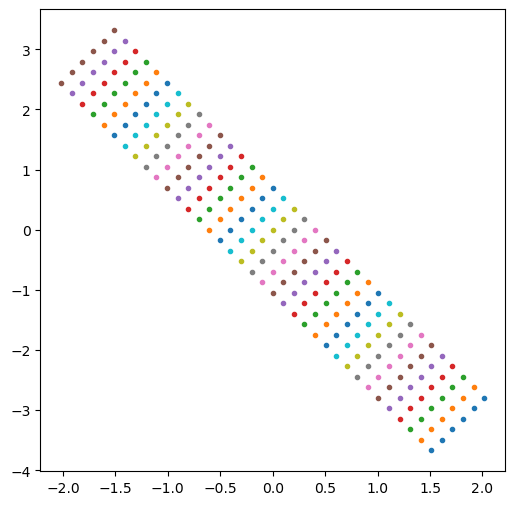

In [ ]:
#Define general parameters
L6=6 
L3=12
 

#Parameters for Partons with C= +1, +1, +1, +1, +1, -5 (all 3 partons in nu=1/3, charge e/3, 1 band filled)
#take the values vals from Fabian's Code
vals1 = 1/9, 0.0, 0.0, np.pi/6, np.pi/3 

#Parameters for Partons with C= -1, -1, -1, -1, -1, +5 (1 parton species in nu=2/3 with charge -e/3, 2 bands filled)
#take the values vals from Fabian's Code
vals21 = 4/9, 0.0, 0.0, -np.pi/6, -np.pi/3

#Parameters for Partons with C= +2, -1, -1 (2 partons of parton species in nu=2/3, charge 2e/3, 1 band filled)
#take the values vals from Fabian's Code
vals22 = 4/9, 0.0, 0.0, np.pi/3

#get eigenvectors and eigenenergies/banddispersion
evals1, evecs1 = get_evals_evecs_6sUC(L6, vals1, a1, a2, h1mm, h2mm)
evals21, evecs21 = get_evals_evecs_6sUC(L6, vals21, a1, a2, h1mm, h2mm)
evals22, evecs22 = get_evals_evecs_3sUC(L3, vals22, a1, a2, h1m, h2m)

#compute Fermi-energy and the chemical potential for nu=1/3 -> Partons have nu=1
E_F11 = get_energy_6sUC(evals1, 0, 1, 6) 
mu_11 = get_chempot_6sUC(evals1, 1, 6)

#compute Fermi-energy and the chemical potential for nu=2/3 
    #for charge -e/3 partons -> Partons have nu=2
E_F21 = get_energy_6sUC(evals21, 0, 2, 6) 
mu_21 = get_chempot_6sUC(evals21, 2, 6)
    #for charge 2e/3 partons -> Partons have nu=1
E_F22 = get_energy_3sUC(evals22, 0, 1, 3) 
mu_22 = get_chempot_3sUC(evals22, 1, 3)

#define Fermi-Dirac and Bose-Einstein summands


#create the grid spanned by h1m, h2m
kGrid_3sUC, kGridMat_3sUC = get_mom_grid_3sUC(L3, h1m, h2m)
kGrid_6sUC, kGridMat_6sUC = get_mom_grid_6sUC(L6, h1mm, h2mm)
kGrid_e, kGridMat_e = get_electron_mom_grid(3*L3, g1, g2)

#get ksi = energy - chempot
ksi1 = get_ksi_6sUC(evals1, mu_11)
ksi21 = get_ksi_6sUC(evals21, mu_21)
ksi22 = get_ksi_3sUC(evals22, mu_22)

import matplotlib.pyplot as plt
plt.figure(figsize=(6,6))
plt.plot(kGridMat_6sUC[:,:,0], kGridMat_6sUC[:,:,1], '.')
plt.show()

In [26]:
def get_C_mat_mat_6sUC(omg_mats, evecs, bands):
    #omg_mats has shape (N)
    q_len = len(bands[:,0,0])
    N = len(omg_mats)
    C_mat = np.full((q_len, 6*q_len, 6, 6, N), None, dtype=complex)
    Z_mat = np.einsum('kpam, kpbm->kpabm', evecs, np.conj(evecs))

    for qq in range(q_len):
        for pp in range(6*q_len):
            for a in range(6):
                for b in range(6):
                    for n in range(N):
                        C_mat[qq, pp, a, b, n] = np.sum(Z_mat[qq, pp, a, b, :]/(omg_mats[n] - bands[qq, pp, :]))             
    return C_mat

def get_C_mat_mat_3sUC(omg_mats, evecs, bands):
    #omg_mats has shape (N)
    q_len = len(bands[:,0,0])
    N = len(omg_mats)
    C_mat = np.full((q_len, 3*q_len, 3, 3, N), None, dtype=complex)
    Z_mat = np.einsum('kpam, kpbm->kpabm', evecs, np.conj(evecs))

    for qq in range(q_len):
        for pp in range(3*q_len):
            for a in range(3):
                for b in range(3):
                    for n in range(N):
                        C_mat[qq, pp, a, b, n] = np.sum(Z_mat[qq, pp, a, b, :]/(omg_mats[n] - bands[qq, pp, :]))             
    return C_mat

def get_C_mat_mat_vec(omg_mats, evecs, bands):
    """
    Vectorized version of get_C_mat_mat.

    Parameters
    ----------
    omg_mats : (N,) complex (or float) array
        Matsubara frequencies ω_n. If real, you can add a small +i*eta shift.
    evecs : (..., a, m) complex array
        Eigenvectors with indices (k, p, a, m) where a is orbital (size 3).
    bands : (k, p, m) real/complex array
        Band energies ε_{kpm}.
    eta : float, optional
        Small positive broadening; uses ω -> ω + i*eta.

    Returns
    -------
    C_mat : (k, p, a, b, N) complex array
        Orbital-resolved matrix for each (k,p) and ω_n:
        C^{ab}_{kp}(ω_n) = Σ_m Z^{ab}_{kpm} / (ω_n - ε_{kpm}),
        with Z^{ab}_{kpm} = evecs_{kpam} * evecs^*_{kpbm}.
    """
    # Projector weights Z_{k p a b m}
    Z_mat = np.einsum('kpam,kpbm->kpabm', evecs, np.conj(evecs))  # (k,p,3,3,m)

    # 1 / (ω_n - ε) for each (k,p,m,n)
    denom_inv = 1.0 / ( (omg_mats[None, None, None, :])  # (1,1,1,N)
                        - bands[..., None] )                      # (k,p,m,1)
    # Make shapes align to (k,p,m,N)
    denom_inv = denom_inv  # (k,p,m,N)

    # Sum over band index m:  (k,p,a,b,m) * (k,p,m,n) -> (k,p,a,b,n)
    C_mat = np.einsum('kpabm,kpmn->kpabn', Z_mat, denom_inv)

    return C_mat


beta = 50 #inverse temperature beta = 50
M = 1000 #number of negative Matsubara frequencies = number of positive Matsubara frequencies = M
omg_mats = 1j*np.pi*(2*np.arange(-M, M+1)+1)/ beta  #Matsubara frequencies, N=2*M+1

G_Parton1_iwn = get_C_mat_mat_vec(omg_mats, evecs1, ksi1) #nu = 1/3 parton with charge -e/3, 1 band filled with C=-1

G_Parton21_iwn = get_C_mat_mat_vec(omg_mats, evecs21, ksi21) #nu = 2/3 parton with charge 2e/3, 2 bands filled C_ges = -1+2=+1
G_Parton22_iwn = get_C_mat_mat_vec(omg_mats, evecs22, ksi22) #nu = 2/3 2 partons with charge e/3, 2 bands filled C_ges = -1-1 =-2

print(np.min(G_Parton1_iwn), np.max(G_Parton1_iwn))
print(np.min(G_Parton21_iwn), np.max(G_Parton21_iwn))
print(np.min(G_Parton22_iwn), np.max(G_Parton22_iwn))
print(np.min(np.abs(G_Parton1_iwn)), np.max(np.abs(G_Parton1_iwn)), np.mean(np.abs(G_Parton1_iwn)))
print(np.min(np.abs(G_Parton21_iwn)), np.max(np.abs(G_Parton21_iwn)), np.mean(np.abs(G_Parton21_iwn)))
print(np.min(np.abs(G_Parton22_iwn)), np.max(np.abs(G_Parton22_iwn)), np.mean(np.abs(G_Parton22_iwn)))

(-5.796380629846048-0.1522526415765967j) (5.796380629846057+0.15225264157662383j)
(-4.948427978262748-2.686992530207197j) (4.8012177800698845+2.941968072869534j)
(-2.9335501039515837-0.7346448853133363j) (3.0660779117111976+0.7679988836682455j)
2.3761100275777587e-17 10.753562632559639 0.013383374318916438
2.6332622536381048e-14 8.548044745221215 0.011894006006421869
2.9812804334415767e-07 3.1607999060362824 0.020086415228790528


1.0000000000000002


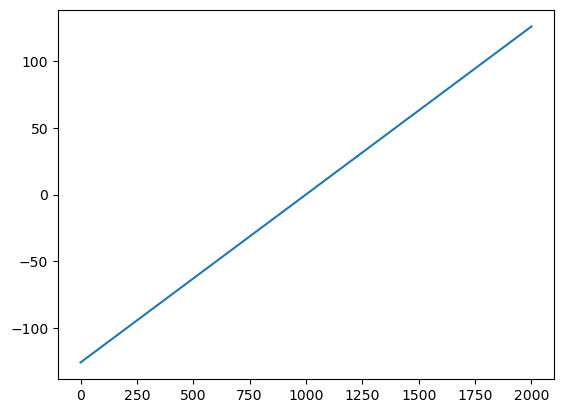

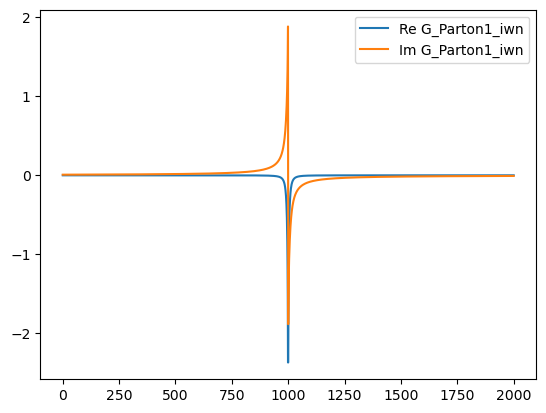

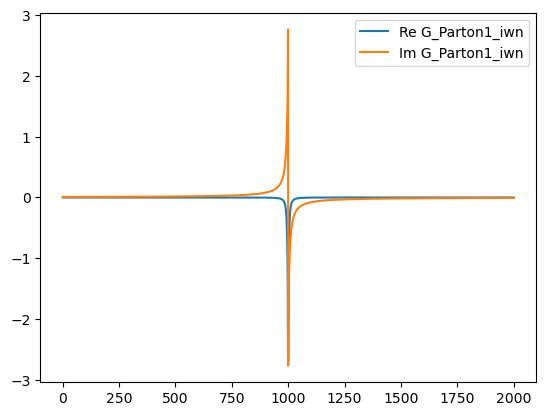

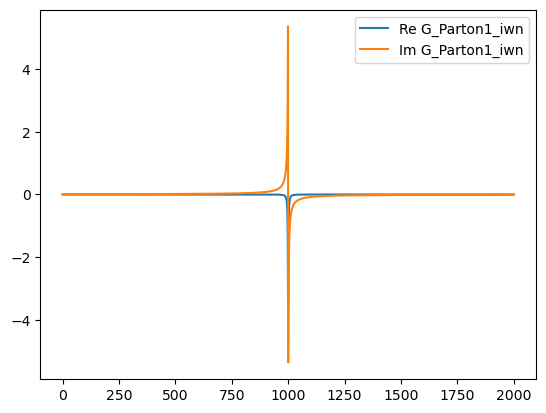

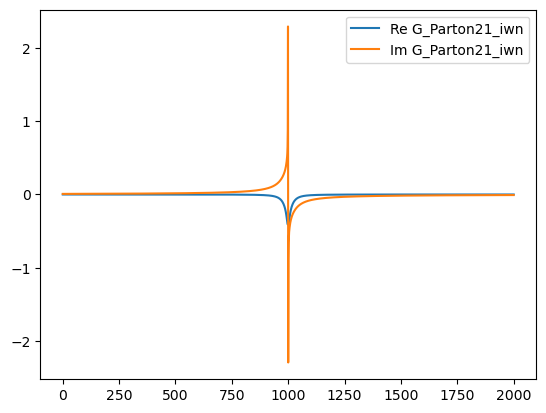

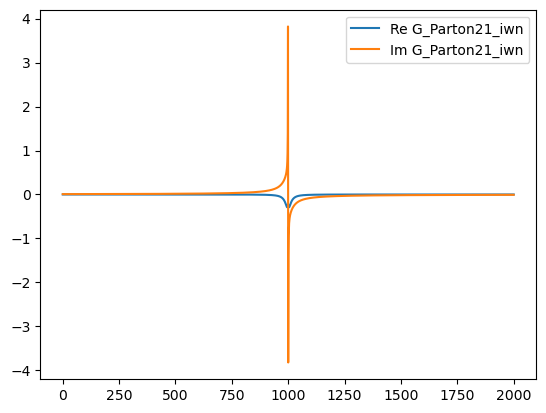

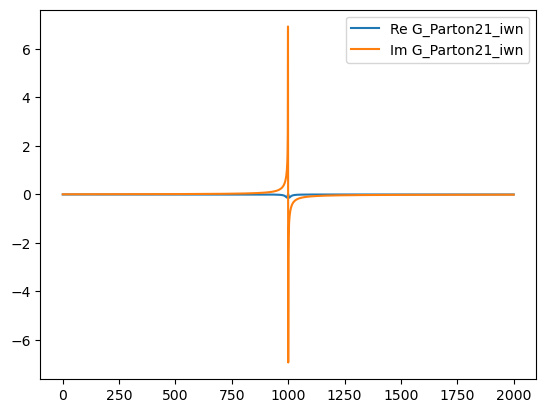

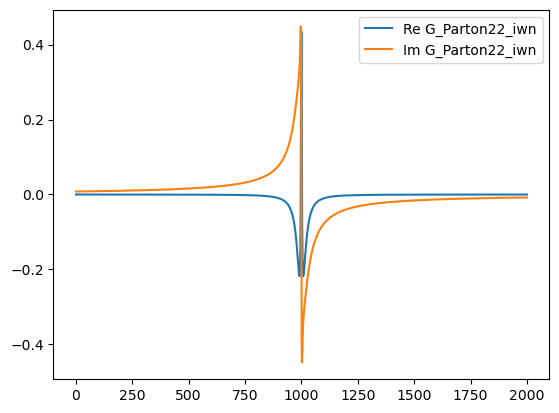

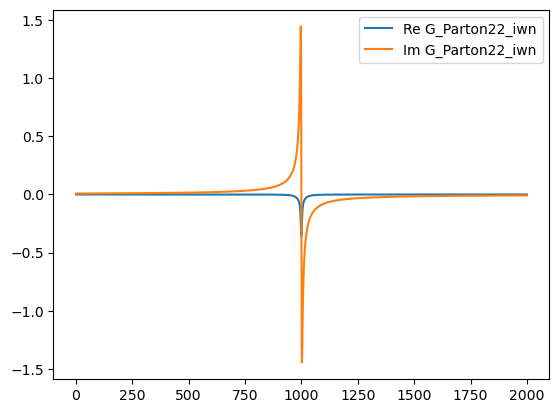

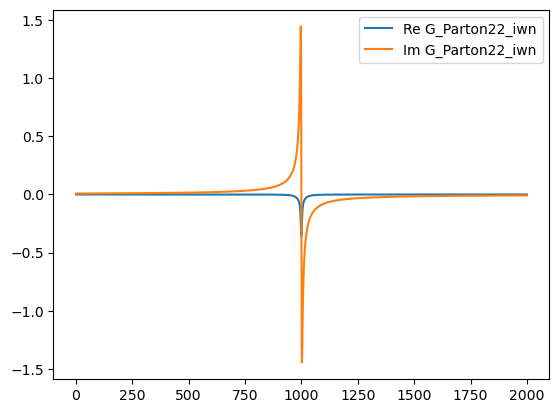

In [28]:
print(np.linalg.norm(evecs1[0,0,2,:]))
plt.plot(np.imag(omg_mats))
plt.show()
plt.plot(np.real(G_Parton1_iwn[L6//2,6*L6//2,0,0,:]), label='Re G_Parton1_iwn')
plt.plot(np.imag(G_Parton1_iwn[L6//2,6*L6//2,0,0,:]), label='Im G_Parton1_iwn')
plt.legend()
plt.show()
plt.plot(np.real(G_Parton1_iwn[L6//2,6*L6//2,1,1,:]), label='Re G_Parton1_iwn')
plt.plot(np.imag(G_Parton1_iwn[L6//2,6*L6//2,1,1,:]), label='Im G_Parton1_iwn')
plt.legend()
plt.show()
plt.plot(np.real(G_Parton1_iwn[L6//2,6*L6//2,2,2,:]), label='Re G_Parton1_iwn')
plt.plot(np.imag(G_Parton1_iwn[L6//2,6*L6//2,2,2,:]), label='Im G_Parton1_iwn')
plt.legend()
plt.show()
plt.plot(np.real(G_Parton21_iwn[L6//2,6*L6//2,0,0,:]), label='Re G_Parton21_iwn')
plt.plot(np.imag(G_Parton21_iwn[L6//2,6*L6//2,0,0,:]), label='Im G_Parton21_iwn')
plt.legend()
plt.show()
plt.plot(np.real(G_Parton21_iwn[L6//2,6*L6//2,1,1,:]), label='Re G_Parton21_iwn')
plt.plot(np.imag(G_Parton21_iwn[L6//2,6*L6//2,1,1,:]), label='Im G_Parton21_iwn')
plt.legend()
plt.show()
plt.plot(np.real(G_Parton21_iwn[L6//2,6*L6//2,2,2,:]), label='Re G_Parton21_iwn')
plt.plot(np.imag(G_Parton21_iwn[L6//2,6*L6//2,2,2,:]), label='Im G_Parton21_iwn')
plt.legend()
plt.show()
plt.plot(np.real(G_Parton22_iwn[L3//2,3*L3//2,0,0,:]), label='Re G_Parton22_iwn')
plt.plot(np.imag(G_Parton22_iwn[L3//2,3*L3//2,0,0,:]), label='Im G_Parton22_iwn')
plt.legend()
plt.show()
plt.plot(np.real(G_Parton22_iwn[L3//2,3*L3//2,1,1,:]), label='Re G_Parton22_iwn')
plt.plot(np.imag(G_Parton22_iwn[L3//2,3*L3//2,1,1,:]), label='Im G_Parton22_iwn')
plt.legend()
plt.show()
plt.plot(np.real(G_Parton22_iwn[L3//2,3*L3//2,2,2,:]), label='Re G_Parton22_iwn')
plt.plot(np.imag(G_Parton22_iwn[L3//2,3*L3//2,2,2,:]), label='Im G_Parton22_iwn')
plt.legend()
plt.show()

In [34]:
#get G^i_ab(x,tau)
def get_G_ab_x_tau(G_ab_iwn_q):
    q_len = len(G_ab_iwn_q[:,0,0,0,0])
    l = len(G_ab_iwn_q[0,0,:,0,0])
    N = len(G_ab_iwn_q[0,0,0,0,:])
    G_x_tau = np.full((q_len, 6*q_len, l, l, N), None, dtype=complex)
    G_iwn_rev = G_ab_iwn_q[:, :, :, :, ::-1] # Reverse the Matsubara frequency order
    m  = np.arange(N)
    ferm_phase = np.exp(-1j * np.pi * (m / N))

    G_x_tau = np.sqrt(N)/beta * fft.ifftn(np.fft.ifftshift(G_iwn_rev, axes=(0, 1, 4)), axes=(0, 1, 4), norm='ortho')
    G_x_tau = G_x_tau * ferm_phase[None, None, None, None, :]
    
    return G_x_tau.astype(np.complex128)

def get_Chi0_ab_x_tau_nu1_3(G1_ab_x_tau, G2_ab_x_tau, G3_ab_x_tau, Fac1, Fac2, Fac3):
    L = len(G1_ab_x_tau[:,0,0,0,0])
    l = len(G1_ab_x_tau[0,0,:,0,0])
    N = len(G1_ab_x_tau[0,0,0,0,:])
    
    idx_minus_r = (-np.arange(L)) % L            # 0→0, 1→L-1, ...
    idy_minus_r = (-np.arange(6*L)) % (6*L)
    idab = np.arange(l)
    idx_beta_minus = (-np.arange(N)) % N      # 0→0, 1→N-1, ...
    G11 = G1_ab_x_tau
    G12 = -np.swapaxes(G1_ab_x_tau[np.ix_(idx_minus_r, idy_minus_r, idab, idab, idx_beta_minus)], 2, 3)
    G12[...,0] *= -1
    G21 = G2_ab_x_tau
    G22 = -np.swapaxes(G2_ab_x_tau[np.ix_(idx_minus_r, idy_minus_r, idab, idab, idx_beta_minus)], 2, 3)
    G22[...,0] *= -1
    G31 = G3_ab_x_tau
    G32 = -np.swapaxes(G3_ab_x_tau[np.ix_(idx_minus_r, idy_minus_r, idab, idab, idx_beta_minus)], 2, 3)
    G32[...,0] *= -1

    Chi0_ab_x_tau_compl = 1/(6*L**2)*Fac2*Fac3*G11*G12+1/(6*L**2)*Fac1*Fac3*G21*G22+1/(6*L**2)*Fac1*Fac2*G31*G32+1/((6*L**2)**3)*G11*G12*G21*G22*G31*G32-1/((6*L**2)**2)*Fac1*G21*G22*G31*G32-1/((6*L**2)**2)*Fac2*G11*G12*G31*G32-1/((6*L**2)**2)*Fac3*G11*G12*G21*G22
    Chi0_ab_x_tau_GGGGGG = 1/((6*L**2)**3)*G11*G12*G21*G22*G31*G32
    Chi0_ab_x_tau_GG1 = 1/(6*L**2)*Fac2*Fac3*G11*G12
    Chi0_ab_x_tau_GG2 = 1/(6*L**2)*Fac1*Fac3*G21*G22
    Chi0_ab_x_tau_GG3 = 1/(6*L**2)*Fac1*Fac2*G31*G32
    Chi0_ab_x_tau_GG1GG3 = -1/((6*L**2)**2)*Fac2*G11*G12*G31*G32
    Chi0_ab_x_tau_GG1GG2 = -1/((6*L**2)**2)*Fac3*G11*G12*G21*G22
    Chi0_ab_x_tau_GG2GG3 = -1/((6*L**2)**2)*Fac1*G21*G22*G31*G32

#PROBLEM FOR GAPLESS: first terms, ESPECIALLY G11G12-term is the PROBLEM!!, but none of them are scaling with L, so the L dependence is correct
    return Chi0_ab_x_tau_compl, Chi0_ab_x_tau_GGGGGG, Chi0_ab_x_tau_GG1, Chi0_ab_x_tau_GG2, Chi0_ab_x_tau_GG3, Chi0_ab_x_tau_GG1GG2, Chi0_ab_x_tau_GG1GG3, Chi0_ab_x_tau_GG2GG3

def get_Chi0_r_tau_nu2_3(G1_ab_x_tau, G2_ab_x_tau, G3_ab_x_tau, Fac1, Fac2, Fac3):
    L6 = len(G1_ab_x_tau[:,0,0,0,0])
    L3 = len(G2_ab_x_tau[:,0,0,0,0])
    l1 = len(G1_ab_x_tau[0,0,:,0,0])
    l2 = len(G2_ab_x_tau[0,0,:,0,0])
    N = len(G1_ab_x_tau[0,0,0,0,:])
    
    idx_minus_r1 = (-np.arange(L6)) % L6            # 0→0, 1→L-1, ...
    idy_minus_r1 = (-np.arange(6*L6)) % (6*L6)
    idx_minus_r2 = (-np.arange(L3)) % L3            # 0→0, 1→L-1, ...
    idy_minus_r2 = (-np.arange(3*L3)) % (3*L3)
    idab1 = np.arange(l1)
    idab2 = np.arange(l2)
    idx_beta_minus = (-np.arange(N)) % N      # 0→0, 1→N-1, ...
    G11 = G1_ab_x_tau
    G12 = -np.swapaxes(G1_ab_x_tau[np.ix_(idx_minus_r1, idy_minus_r1, idab1, idab1, idx_beta_minus)], 2, 3)
    G12[...,0] *= -1
    G21 = G2_ab_x_tau
    G22 = -np.swapaxes(G2_ab_x_tau[np.ix_(idx_minus_r2, idy_minus_r2, idab2, idab2, idx_beta_minus)], 2, 3)
    G22[...,0] *= -1
    G31 = G3_ab_x_tau
    G32 = -np.swapaxes(G3_ab_x_tau[np.ix_(idx_minus_r2, idy_minus_r2, idab2, idab2, idx_beta_minus)], 2, 3)
    G32[...,0] *= -1

    GG1 = G11*G12
    GG2 = G21*G22
    GG3 = G31*G32
    
    GG1_r_tau = get_Chi0_r_tau_6sUC(GG1)
    GG2_r_tau = get_Chi0_r_tau_3sUC(GG2)
    GG3_r_tau = get_Chi0_r_tau_3sUC(GG3)

    Chi0_r_tau_compl = 1/(36*L6**2)*Fac2*Fac3*GG1_r_tau+1/(36*L6**2)*Fac1*Fac3*GG2_r_tau+1/(36*L6**2)*Fac1*Fac2*GG3_r_tau+1/((36*L6**2)**3)*GG1_r_tau*GG2_r_tau*GG3_r_tau-1/((36*L6**2)**2)*Fac1*GG2_r_tau*GG3_r_tau-1/((36*L6**2)**2)*Fac2*GG1_r_tau*GG3_r_tau-1/((36*L6**2)**2)*Fac3*GG1_r_tau*GG2_r_tau
    Chi0_r_tau_GGGGGG = 1/((36*L6**2)**3)*GG1_r_tau*GG2_r_tau*GG3_r_tau
    Chi0_r_tau_GG1 = 1/(36*L6**2)*Fac2*Fac3*GG1_r_tau
    Chi0_r_tau_GG2 = 1/(36*L6**2)*Fac1*Fac3*GG2_r_tau
    Chi0_r_tau_GG3 = 1/(36*L6**2)*Fac1*Fac2*GG3_r_tau
    Chi0_r_tau_GG1GG3 = -1/((36*L6**2)**2)*Fac2*GG1_r_tau*GG3_r_tau
    Chi0_r_tau_GG1GG2 = -1/((36*L6**2)**2)*Fac3*GG1_r_tau*GG2_r_tau
    Chi0_r_tau_GG2GG3 = -1/((36*L6**2)**2)*Fac1*GG2_r_tau*GG3_r_tau

    return Chi0_r_tau_compl, Chi0_r_tau_GGGGGG, Chi0_r_tau_GG1, Chi0_r_tau_GG2, Chi0_r_tau_GG3, Chi0_r_tau_GG1GG2, Chi0_r_tau_GG1GG3, Chi0_r_tau_GG2GG3

def get_Chi0_r_tau_6sUC(Chi0_ab_x_tau):
    L = len(Chi0_ab_x_tau[:,0,0,0,0])
    l = len(Chi0_ab_x_tau[0,0,:,0,0])
    N = len(Chi0_ab_x_tau[0,0,0,0,:])
    Chi0_r_tau = np.zeros((6*L,6*L,N), dtype=np.complex128)
    for xx in range(L):
        for yy in range(6*L):
            for a in range(l):
                Chi0_r_tau[6*xx+a,yy,:] = Chi0_ab_x_tau[xx,yy,a,0,:]
    return Chi0_r_tau

def get_Chi0_r_tau_3sUC(Chi0_ab_x_tau):
    L = len(Chi0_ab_x_tau[:,0,0,0,0])
    l = len(Chi0_ab_x_tau[0,0,:,0,0])
    N = len(Chi0_ab_x_tau[0,0,0,0,:])
    Chi0_r_tau = np.zeros((3*L,3*L,N), dtype=np.complex128)
    for xx in range(L):
        for yy in range(3*L):
            for a in range(l):
                Chi0_r_tau[3*xx+a,yy,:] = Chi0_ab_x_tau[xx,yy,a,0,:]
    return Chi0_r_tau


def get_Chi0_k_ivn(Chi0_r_tau):
    N = len(Chi0_r_tau[0,0,:])
    Chi0_k_ivn_rev = fft.fftn(Chi0_r_tau, axes=(0, 1, 2))
    Chi0_k_ivn_rev = fft.fftshift(Chi0_k_ivn_rev, axes=(0, 1, 2))
    Chi0_k_ivn = Chi0_k_ivn_rev[:, :, ::-1] # Reverse the Matsubara frequency order

    # Include β for the τ integral (since τ grid is mβ/N and NumPy's FFT is a plain sum)
    Chi0_k_ivn *= beta/N
 
    return Chi0_k_ivn.astype(np.complex128)
    
def get_Chi0_ab_q_ivn(Chi0_ab_x_tau):
    N = len(Chi0_ab_x_tau[0,0,0,0,:])
    Chi0_ab_q_ivn_rev = fft.fftn(Chi0_ab_x_tau, axes=(0, 1, 4))
    Chi0_ab_q_ivn_rev = fft.fftshift(Chi0_ab_q_ivn_rev, axes=(0, 1, 4))
    Chi0_ab_q_ivn = Chi0_ab_q_ivn_rev[:, :, :, :, ::-1] # Reverse the Matsubara frequency order

    # Include β for the τ integral (since τ grid is mβ/N and NumPy's FFT is a plain sum)
    Chi0_ab_q_ivn *= beta/N
 
    return Chi0_ab_q_ivn.astype(np.complex128)

def get_Chi0_k_ivn_ALT_6sUC(Chi0_ab_q_ivn):
    N = len(Chi0_ab_q_ivn[0,0,0,0,:])
    L = len(Chi0_ab_q_ivn[:,0,0,0,0])
    Chi0_k_ivn_ALT = np.zeros((6*L, 6*L, N), dtype=np.complex128)
    for kx in range(-(6*L)//2, (6*L)//2):
        for ky in range(-(6*L)//2, (6*L)//2):
            for a in range(6):
                for b in range(6):
                    Chi0_k_ivn_ALT[kx+(6*L)//2,ky+(6*L)//2,:] += Chi0_ab_q_ivn[(kx+(6*L)//2)%L, (ky+(6*L)//2)%(6*L), a, b, :]*np.exp(1j*kx*(a-b)*2*np.pi/(6*L))
    return Chi0_k_ivn_ALT

In [ ]:
#final calculation of all Greensfunctions and susceptibilities
Fac11 = 1#noch korrekt zu berechnen !!!
Fac21 = 1#noch korrekt zu berechnen !!!
Fac22 = 1#noch korrekt zu berechnen !!!

def get_Chi0_q_ivn_nu1_3_all(G1iwn, G2iwn, G3iwn, Fac1, Fac2, Fac3):
    G1_ab_x_tau = get_G_ab_x_tau(G1iwn)
    G2_ab_x_tau = get_G_ab_x_tau(G2iwn)
    G3_ab_x_tau = get_G_ab_x_tau(G3iwn)
    Chi0_ab_x_tau_compl, Chi0_ab_x_tau_GGGGGG, Chi0_ab_x_tau_GG1, Chi0_ab_x_tau_GG2, Chi0_ab_x_tau_GG3, Chi0_ab_x_tau_GG1GG2, Chi0_ab_x_tau_GG1GG3, Chi0_ab_x_tau_GG2GG3 = get_Chi0_ab_x_tau_nu1_3(G1_ab_x_tau, G2_ab_x_tau, G3_ab_x_tau, Fac1, Fac2, Fac3)
    Chi0_r_tau_compl = get_Chi0_r_tau_6sUC(Chi0_ab_x_tau_compl)
    Chi0_r_tau_GGGGGG = get_Chi0_r_tau_6sUC(Chi0_ab_x_tau_GGGGGG)
    Chi0_r_tau_GG1 = get_Chi0_r_tau_6sUC(Chi0_ab_x_tau_GG1)
    Chi0_r_tau_GG2 = get_Chi0_r_tau_6sUC(Chi0_ab_x_tau_GG2)
    Chi0_r_tau_GG3 = get_Chi0_r_tau_6sUC(Chi0_ab_x_tau_GG3)
    Chi0_r_tau_GG1GG2 = get_Chi0_r_tau_6sUC(Chi0_ab_x_tau_GG1GG2)
    Chi0_r_tau_GG1GG3 = get_Chi0_r_tau_6sUC(Chi0_ab_x_tau_GG1GG3)
    Chi0_r_tau_GG2GG3 = get_Chi0_r_tau_6sUC(Chi0_ab_x_tau_GG2GG3)
    Chi0_k_ivn_compl = get_Chi0_k_ivn(Chi0_r_tau_compl)
    Chi0_k_ivn_GGGGGG = get_Chi0_k_ivn(Chi0_r_tau_GGGGGG)
    Chi0_k_ivn_GG1 = get_Chi0_k_ivn(Chi0_r_tau_GG1)
    Chi0_k_ivn_GG2 = get_Chi0_k_ivn(Chi0_r_tau_GG2)
    Chi0_k_ivn_GG3 = get_Chi0_k_ivn(Chi0_r_tau_GG3)
    Chi0_k_ivn_GG1GG2 = get_Chi0_k_ivn(Chi0_r_tau_GG1GG2)
    Chi0_k_ivn_GG1GG3 = get_Chi0_k_ivn(Chi0_r_tau_GG1GG3)
    Chi0_k_ivn_GG2GG3 = get_Chi0_k_ivn(Chi0_r_tau_GG2GG3)
    return Chi0_k_ivn_compl, Chi0_k_ivn_GGGGGG, Chi0_k_ivn_GG1, Chi0_k_ivn_GG2, Chi0_k_ivn_GG3, Chi0_k_ivn_GG1GG2, Chi0_k_ivn_GG1GG3, Chi0_k_ivn_GG2GG3

def get_Chi0_q_ivn_nu2_3_all(G1iwn, G2iwn, G3iwn, Fac1, Fac2, Fac3):
    G1_ab_x_tau = get_G_ab_x_tau(G1iwn)
    G2_ab_x_tau = get_G_ab_x_tau(G2iwn)
    G3_ab_x_tau = get_G_ab_x_tau(G3iwn)
    Chi0_r_tau_compl, Chi0_r_tau_GGGGGG, Chi0_r_tau_GG1, Chi0_r_tau_GG2, Chi0_r_tau_GG3, Chi0_r_tau_GG1GG2, Chi0_r_tau_GG1GG3, Chi0_r_tau_GG2GG3 = get_Chi0_r_tau_nu2_3(G1_ab_x_tau, G2_ab_x_tau, G3_ab_x_tau, Fac1, Fac2, Fac3)
    Chi0_k_ivn_compl = get_Chi0_k_ivn(Chi0_r_tau_compl)
    Chi0_k_ivn_GGGGGG = get_Chi0_k_ivn(Chi0_r_tau_GGGGGG)
    Chi0_k_ivn_GG1 = get_Chi0_k_ivn(Chi0_r_tau_GG1)
    Chi0_k_ivn_GG2 = get_Chi0_k_ivn(Chi0_r_tau_GG2)
    Chi0_k_ivn_GG3 = get_Chi0_k_ivn(Chi0_r_tau_GG3)
    Chi0_k_ivn_GG1GG2 = get_Chi0_k_ivn(Chi0_r_tau_GG1GG2)
    Chi0_k_ivn_GG1GG3 = get_Chi0_k_ivn(Chi0_r_tau_GG1GG3)
    Chi0_k_ivn_GG2GG3 = get_Chi0_k_ivn(Chi0_r_tau_GG2GG3)
    return Chi0_k_ivn_compl, Chi0_k_ivn_GGGGGG, Chi0_k_ivn_GG1, Chi0_k_ivn_GG2, Chi0_k_ivn_GG3, Chi0_k_ivn_GG1GG2, Chi0_k_ivn_GG1GG3, Chi0_k_ivn_GG2GG3

def get_Chi0_q_ivn_nu1_3_all_ALT(G1iwn, G2iwn, G3iwn, Fac1, Fac2, Fac3):
    G1_ab_x_tau = get_G_ab_x_tau(G1iwn)
    G2_ab_x_tau = get_G_ab_x_tau(G2iwn)
    G3_ab_x_tau = get_G_ab_x_tau(G3iwn)
    Chi0_ab_x_tau_compl, Chi0_ab_x_tau_GGGGGG, Chi0_ab_x_tau_GG1, Chi0_ab_x_tau_GG2, Chi0_ab_x_tau_GG3, Chi0_ab_x_tau_GG1GG2, Chi0_ab_x_tau_GG1GG3, Chi0_ab_x_tau_GG2GG3 = get_Chi0_ab_x_tau_nu1_3(G1_ab_x_tau, G2_ab_x_tau, G3_ab_x_tau, Fac1, Fac2, Fac3)
    Chi0_ab_q_ivn_compl = get_Chi0_ab_q_ivn(Chi0_ab_x_tau_compl)
    Chi0_ab_q_ivn_GGGGGG = get_Chi0_ab_q_ivn(Chi0_ab_x_tau_GGGGGG)
    Chi0_ab_q_ivn_GG1 = get_Chi0_ab_q_ivn(Chi0_ab_x_tau_GG1)
    Chi0_ab_q_ivn_GG2 = get_Chi0_ab_q_ivn(Chi0_ab_x_tau_GG2)
    Chi0_ab_q_ivn_GG3 = get_Chi0_ab_q_ivn(Chi0_ab_x_tau_GG3)
    Chi0_ab_q_ivn_GG1GG2 = get_Chi0_ab_q_ivn(Chi0_ab_x_tau_GG1GG2)
    Chi0_ab_q_ivn_GG1GG3 = get_Chi0_ab_q_ivn(Chi0_ab_x_tau_GG1GG3)
    Chi0_ab_q_ivn_GG2GG3 = get_Chi0_ab_q_ivn(Chi0_ab_x_tau_GG2GG3)
    Chi0_k_ivn_compl = get_Chi0_k_ivn_ALT_6sUC(Chi0_ab_q_ivn_compl)
    Chi0_k_ivn_GGGGGG = get_Chi0_k_ivn_ALT_6sUC(Chi0_ab_q_ivn_GGGGGG)
    Chi0_k_ivn_GG1 = get_Chi0_k_ivn_ALT_6sUC(Chi0_ab_q_ivn_GG1)
    Chi0_k_ivn_GG2 = get_Chi0_k_ivn_ALT_6sUC(Chi0_ab_q_ivn_GG2)
    Chi0_k_ivn_GG3 = get_Chi0_k_ivn_ALT_6sUC(Chi0_ab_q_ivn_GG3)
    Chi0_k_ivn_GG1GG2 = get_Chi0_k_ivn_ALT_6sUC(Chi0_ab_q_ivn_GG1GG2)
    Chi0_k_ivn_GG1GG3 = get_Chi0_k_ivn_ALT_6sUC(Chi0_ab_q_ivn_GG1GG3)
    Chi0_k_ivn_GG2GG3 = get_Chi0_k_ivn_ALT_6sUC(Chi0_ab_q_ivn_GG2GG3)
    return Chi0_k_ivn_compl, Chi0_k_ivn_GGGGGG, Chi0_k_ivn_GG1, Chi0_k_ivn_GG2, Chi0_k_ivn_GG3, Chi0_k_ivn_GG1GG2, Chi0_k_ivn_GG1GG3, Chi0_k_ivn_GG2GG3

Chi01_q_ivn_compl, Chi01_q_ivn_GGGGGG, Chi01_q_ivn_GG1, Chi01_q_ivn_GG2, Chi01_q_ivn_GG3, Chi01_q_ivn_GG1GG2, Chi01_q_ivn_GG1GG3, Chi01_q_ivn_GG2GG3 = get_Chi0_q_ivn_nu1_3_all_ALT(G_Parton1_iwn, G_Parton1_iwn, G_Parton1_iwn, Fac11, Fac11, Fac11)
Chi02_q_ivn_compl, Chi02_q_ivn_GGGGGG, Chi02_q_ivn_GG1, Chi02_q_ivn_GG2, Chi02_q_ivn_GG3, Chi02_q_ivn_GG1GG2, Chi02_q_ivn_GG1GG3, Chi02_q_ivn_GG2GG3 = get_Chi0_q_ivn_nu2_3_all(G_Parton21_iwn, G_Parton22_iwn, G_Parton22_iwn, Fac21, Fac22, Fac22)
